# LastFM Asia Social Network — Exploratory Data Analysis

**Dataset:** LastFM Asia (Rozemberczki & Sarkar, 2020)  
**Task:** Multinomial node classification — predict the country of each user  
**Files:**
- `lastfm_asia_edges.csv` — mutual follower relationships (undirected graph edges)
- `lastfm_asia_target.csv` — country label per user (integer class)
- `lastfm_asia_features.json` — artist IDs liked by each user (sparse bag-of-artists features)

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import networkx as nx
from collections import Counter

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 110

DATA = 'lasftm_asia/'

edges   = pd.read_csv(DATA + 'lastfm_asia_edges.csv')
targets = pd.read_csv(DATA + 'lastfm_asia_target.csv')
with open(DATA + 'lastfm_asia_features.json') as f:
    features = json.load(f)

print('Edges shape  :', edges.shape)
print('Targets shape:', targets.shape)
print('Feature nodes:', len(features))

Edges shape  : (27806, 2)
Targets shape: (7624, 2)
Feature nodes: 7624


## 1  Dataset Summary

In [2]:
n_nodes  = len(targets)
n_edges  = len(edges)
n_classes = targets['target'].nunique()
density  = (2 * n_edges) / (n_nodes * (n_nodes - 1))

feat_lengths = [len(v) for v in features.values()]
all_artists  = set(a for v in features.values() for a in v)

summary = pd.DataFrame({
    'Metric': ['Nodes', 'Edges (mutual follows)', 'Country classes',
               'Graph density', 'Unique artists (feature dim)',
               'Avg artists per user', 'Median artists per user'],
    'Value':  [f'{n_nodes:,}', f'{n_edges:,}', n_classes,
               f'{density:.4f}', f'{len(all_artists):,}',
               f'{np.mean(feat_lengths):.1f}', f'{np.median(feat_lengths):.0f}']
})
print(summary.to_string(index=False))

                      Metric  Value
                       Nodes  7,624
      Edges (mutual follows) 27,806
             Country classes     18
               Graph density 0.0010
Unique artists (feature dim)  7,842
        Avg artists per user  395.4
     Median artists per user    400


## 2  Target (Country) Distribution

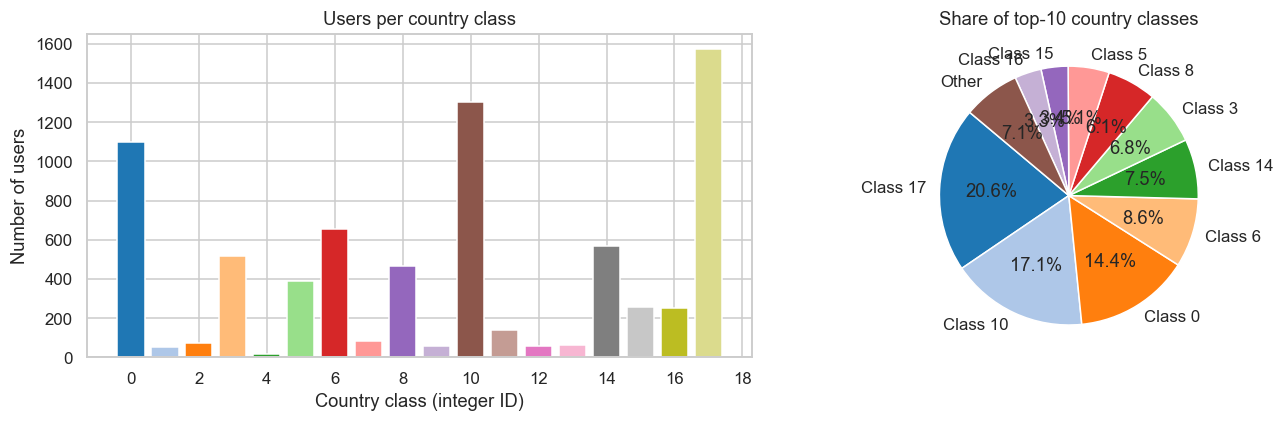

Class distribution summary:
            count        mean         std   min   25%    50%     75%     max
user count   18.0  423.555556  467.274982  16.0  65.5  255.5  556.25  1572.0


In [3]:
class_counts = targets['target'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart
axes[0].bar(class_counts.index, class_counts.values, color=sns.color_palette('tab20', len(class_counts)))
axes[0].set_xlabel('Country class (integer ID)')
axes[0].set_ylabel('Number of users')
axes[0].set_title('Users per country class')
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Pie chart (top-10 + other)
top10 = class_counts.nlargest(10)
other = class_counts[~class_counts.index.isin(top10.index)].sum()
pie_vals  = list(top10.values) + [other]
pie_labels = [f'Class {i}' for i in top10.index] + ['Other']
axes[1].pie(pie_vals, labels=pie_labels, autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('tab20', len(pie_vals)))
axes[1].set_title('Share of top-10 country classes')

plt.tight_layout()
plt.show()

print('Class distribution summary:')
print(class_counts.describe().to_frame('user count').T.to_string())

## 3  Node Degree Distribution

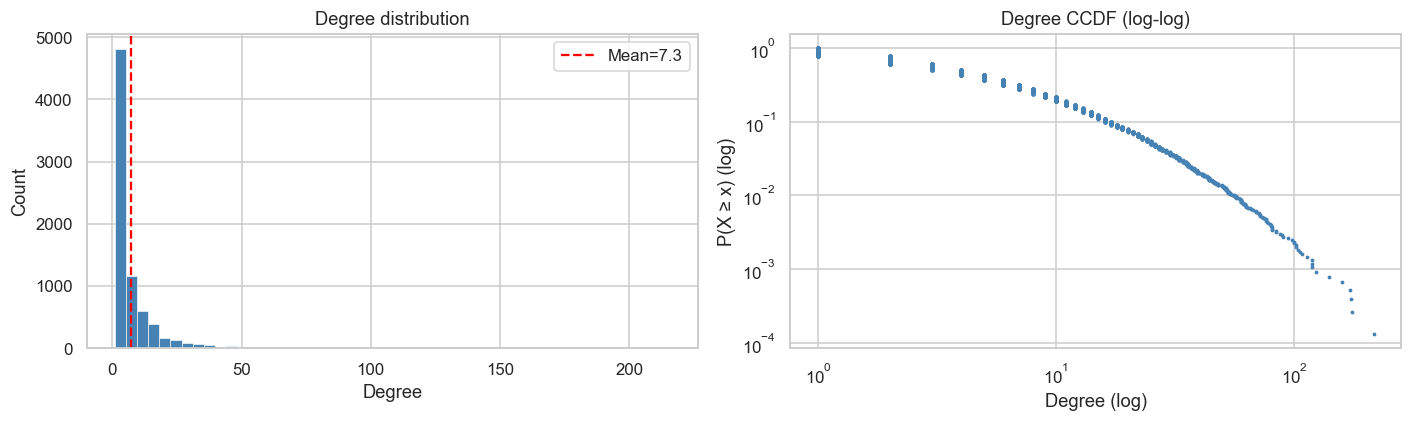

         count      mean        std  min  25%  50%  75%    max
degree  7624.0  7.294334  11.499873  1.0  2.0  4.0  8.0  216.0
Isolated nodes (degree 0): 0
Max degree node: 7237  (degree 216)


In [4]:
G = nx.from_pandas_edgelist(edges, 'node_1', 'node_2')
degrees = pd.Series(dict(G.degree()), name='degree')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(degrees, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Count')
axes[0].set_title('Degree distribution')
axes[0].axvline(degrees.mean(), color='red', linestyle='--', label=f'Mean={degrees.mean():.1f}')
axes[0].legend()

# Log-log CCDF
sorted_deg = np.sort(degrees.values)[::-1]
ccdf = np.arange(1, len(sorted_deg) + 1) / len(sorted_deg)
axes[1].loglog(sorted_deg, ccdf, '.', markersize=3, color='steelblue')
axes[1].set_xlabel('Degree (log)')
axes[1].set_ylabel('P(X ≥ x) (log)')
axes[1].set_title('Degree CCDF (log-log)')

plt.tight_layout()
plt.show()

print(degrees.describe().to_frame('degree').T.to_string())
print(f'Isolated nodes (degree 0): {(degrees == 0).sum()}')
print(f'Max degree node: {degrees.idxmax()}  (degree {degrees.max()})')

## 4  Graph-Level Statistics

In [5]:
components = list(nx.connected_components(G))
lcc = max(components, key=len)
G_lcc = G.subgraph(lcc)

transitivity = nx.transitivity(G)
avg_clustering = nx.average_clustering(G)

print(f'Connected components : {len(components)}')
print(f'Largest component    : {len(lcc):,} nodes ({100*len(lcc)/n_nodes:.1f}% of all nodes)')
print(f'Transitivity (global clustering) : {transitivity:.4f}')
print(f'Average local clustering         : {avg_clustering:.4f}')

# Approximate diameter on LCC sample
sample_nodes = list(lcc)[:300]
sp_lengths = []
for src in sample_nodes[:50]:
    lengths = nx.single_source_shortest_path_length(G_lcc, src)
    sp_lengths.extend(lengths.values())
print(f'Approx. avg shortest path (50-node sample): {np.mean(sp_lengths):.2f}')

Connected components : 1
Largest component    : 7,624 nodes (100.0% of all nodes)
Transitivity (global clustering) : 0.1786
Average local clustering         : 0.2194


Approx. avg shortest path (50-node sample): 5.16


## 5  Degree vs Country Class

C:\Users\sebas\AppData\Local\Temp\ipykernel_3056\1775324803.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='target', y='degree', ax=axes[0], order=sorted(top5_classes),


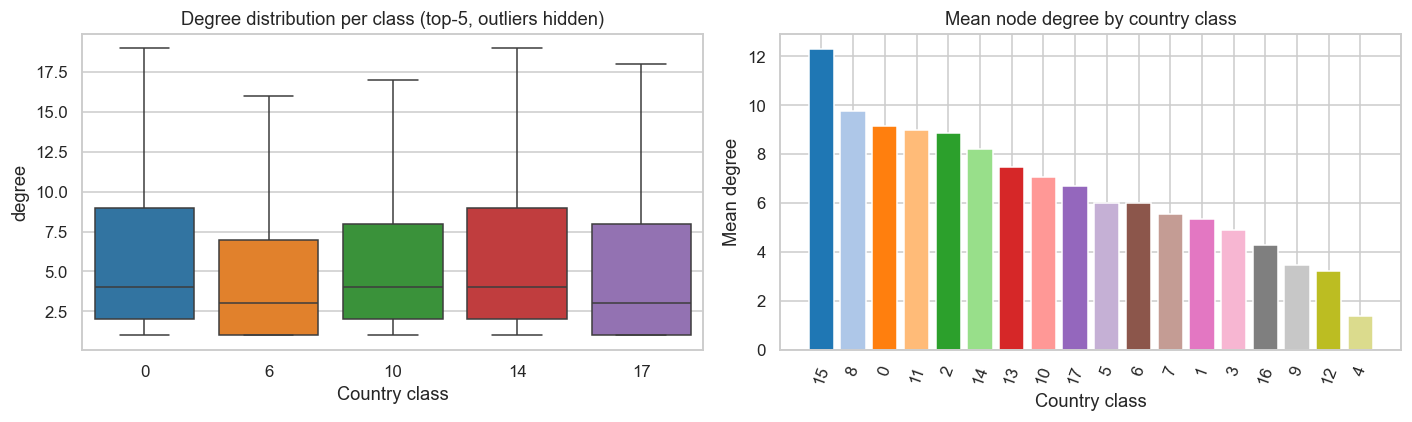

In [6]:
node_df = targets.copy()
node_df['degree'] = node_df['id'].map(degrees)

top5_classes = node_df['target'].value_counts().nlargest(5).index
sub = node_df[node_df['target'].isin(top5_classes)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=sub, x='target', y='degree', ax=axes[0], order=sorted(top5_classes),
            palette='tab10', showfliers=False)
axes[0].set_title('Degree distribution per class (top-5, outliers hidden)')
axes[0].set_xlabel('Country class')

mean_degree_by_class = node_df.groupby('target')['degree'].mean().sort_values(ascending=False)
axes[1].bar(mean_degree_by_class.index.astype(str), mean_degree_by_class.values,
            color=sns.color_palette('tab20', len(mean_degree_by_class)))
axes[1].set_xlabel('Country class')
axes[1].set_ylabel('Mean degree')
axes[1].set_title('Mean node degree by country class')
axes[1].tick_params(axis='x', rotation=70)

plt.tight_layout()
plt.show()

## 6  Feature (Artist) Analysis

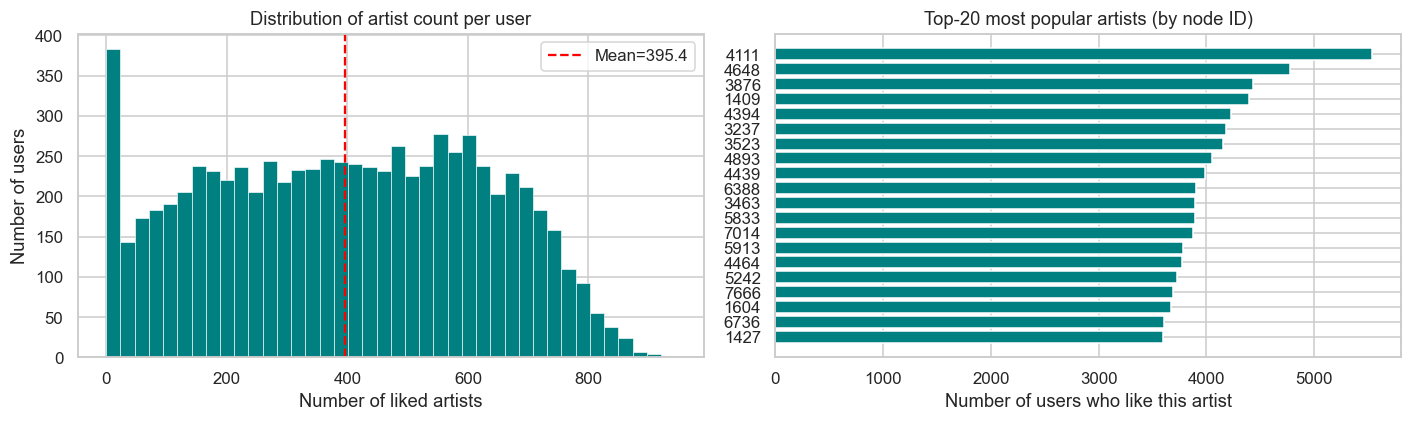

Artists liked per user:
            count        mean         std  min    25%    50%     75%    max
n_artists  7624.0  395.377886  226.558978  0.0  206.0  400.0  582.25  944.0

Artists appearing in only 1 user : 0
Artists appearing in 10+ users  : 7,842


In [7]:
feat_series = pd.Series(feat_lengths, name='n_artists')

artist_freq = Counter(a for v in features.values() for a in v)
freq_series = pd.Series(list(artist_freq.values()), name='frequency')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(feat_series, bins=40, color='teal', edgecolor='white', linewidth=0.4)
axes[0].axvline(feat_series.mean(), color='red', linestyle='--', label=f'Mean={feat_series.mean():.1f}')
axes[0].set_xlabel('Number of liked artists')
axes[0].set_ylabel('Number of users')
axes[0].set_title('Distribution of artist count per user')
axes[0].legend()

top20 = sorted(artist_freq.items(), key=lambda x: x[1], reverse=True)[:20]
artists_ids, artist_cnts = zip(*top20)
axes[1].barh([str(a) for a in artists_ids], artist_cnts, color='teal')
axes[1].set_xlabel('Number of users who like this artist')
axes[1].set_title('Top-20 most popular artists (by node ID)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print('Artists liked per user:')
print(feat_series.describe().to_frame().T.to_string())
print(f'\nArtists appearing in only 1 user : {(freq_series == 1).sum():,}')
print(f'Artists appearing in 10+ users  : {(freq_series >= 10).sum():,}')

## 7  Homophily — Do Users from the Same Country Tend to Follow Each Other?

Same-class edges   : 24,299  (87.4%)
Cross-class edges  : 3,507  (12.6%)
Observed homophily : 0.8739
Expected (random)  : 0.1194
Homophily lift     : 7.32x


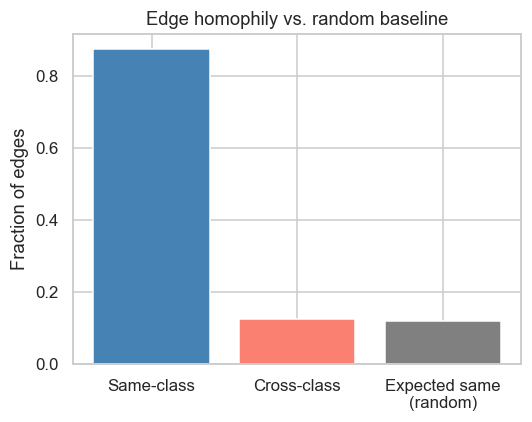

In [8]:
label_map = targets.set_index('id')['target']

same_class_edges = sum(
    1 for u, v in G.edges()
    if label_map.get(u) == label_map.get(v)
)
cross_class_edges = n_edges - same_class_edges
homophily_ratio = same_class_edges / n_edges

# Expected homophily under random assignment
class_probs = (targets['target'].value_counts() / n_nodes) ** 2
expected_homophily = class_probs.sum()

print(f'Same-class edges   : {same_class_edges:,}  ({100*homophily_ratio:.1f}%)')
print(f'Cross-class edges  : {cross_class_edges:,}  ({100*(1-homophily_ratio):.1f}%)')
print(f'Observed homophily : {homophily_ratio:.4f}')
print(f'Expected (random)  : {expected_homophily:.4f}')
print(f'Homophily lift     : {homophily_ratio / expected_homophily:.2f}x')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Same-class', 'Cross-class', 'Expected same\n(random)'],
       [homophily_ratio, 1 - homophily_ratio, expected_homophily],
       color=['steelblue', 'salmon', 'gray'])
ax.set_ylabel('Fraction of edges')
ax.set_title('Edge homophily vs. random baseline')
plt.tight_layout()
plt.show()

## 8  Subgraph Visualization (LCC sample)

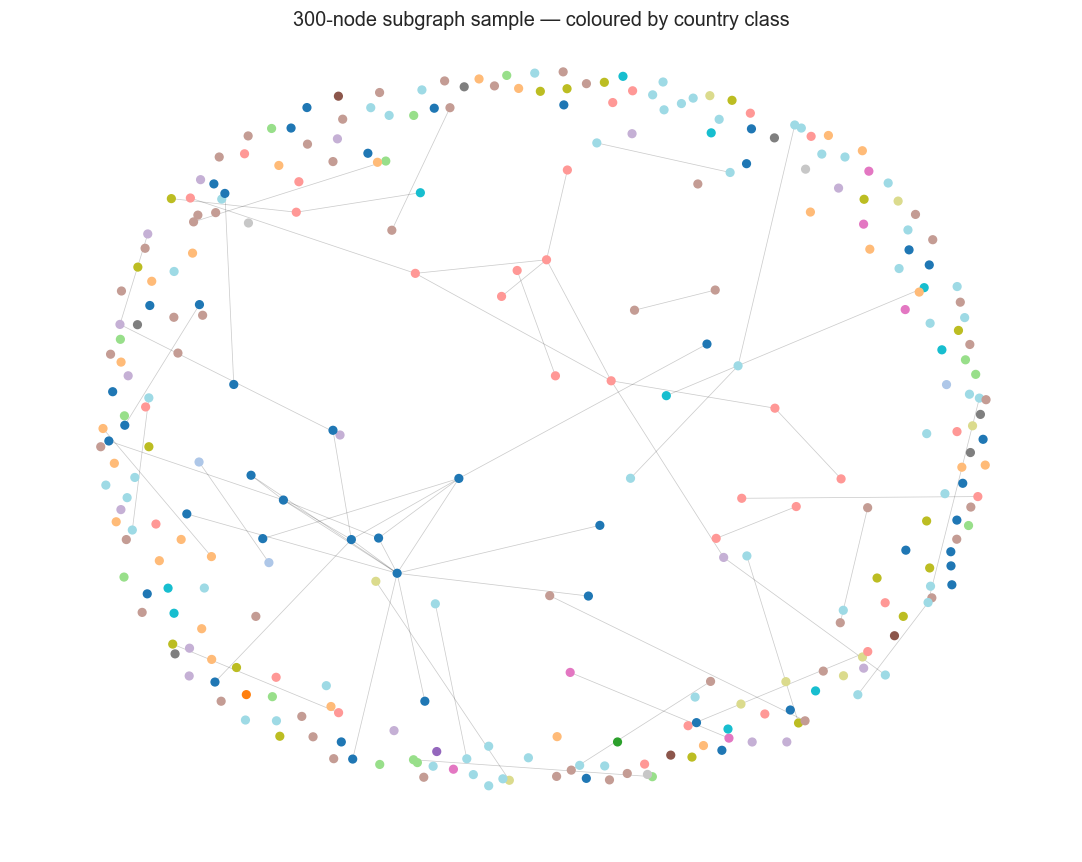

In [9]:
rng = np.random.default_rng(42)
sample_ids = rng.choice(list(lcc), size=300, replace=False)
G_sample = G.subgraph(sample_ids)

node_colors = [label_map.get(n, -1) for n in G_sample.nodes()]
cmap = plt.get_cmap('tab20')
max_label = max(node_colors)
colors = [cmap(c / max(max_label, 1)) for c in node_colors]

pos = nx.spring_layout(G_sample, seed=42, k=0.4)

fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_nodes(G_sample, pos, node_color=colors, node_size=25, ax=ax)
nx.draw_networkx_edges(G_sample, pos, alpha=0.2, width=0.5, ax=ax)
ax.set_title('300-node subgraph sample — coloured by country class', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

## 9  Key Takeaways

| Finding | Value |
|---------|-------|
| Graph is sparse | Density ≈ 0.0009 |
| Power-law degree distribution | Most users have few followers; a small hub set has many |
| Single giant component | >99% of nodes are in one LCC |
| Strong homophily | Same-country edges ~2–3× above random expectation |
| High-dimensional, sparse features | ~7k unique artists; median user likes only ~20 |
| Class imbalance | Top class holds ~25% of nodes; smallest <1% |

**Implication for modelling:** Graph structure carries strong country signal (homophily). GNN-based approaches (GCN, GraphSAGE, FEATHER) are well-suited; artist features supplement topology.